In [1]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from fastai.vision.all import *
from monai.utils import set_determinism

<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [2]:
torch.cuda.get_device_name(0)

'Quadro RTX 4000'

In [3]:
bs, size = 8, 2048
# arch = models.resnet34
path = Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset')
#path = Path('../_data/Babesia/')
path_x = path/'inputs'
path_y = path/'targets'

In [4]:
from bioMONAI.core import get_target
get_target(path_y, same_filename=True)(path / 'sample_1.png')

Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/targets/sample_1.png')

In [5]:
from bioMONAI.core import get_target
from bioMONAI.transforms import RandCrop2D
from bioMONAI.transforms import RandCropND
from monai.transforms import ScaleIntensity

dblock = DataBlock(blocks=(ImageBlock(cls=PILImageBW), ImageBlock(cls=PILImageBW)),
                   get_items=get_image_files,
                   get_y=get_target(path_y, same_filename=True),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=[RandomCrop(256),FlipItem(0.5)],
                  )

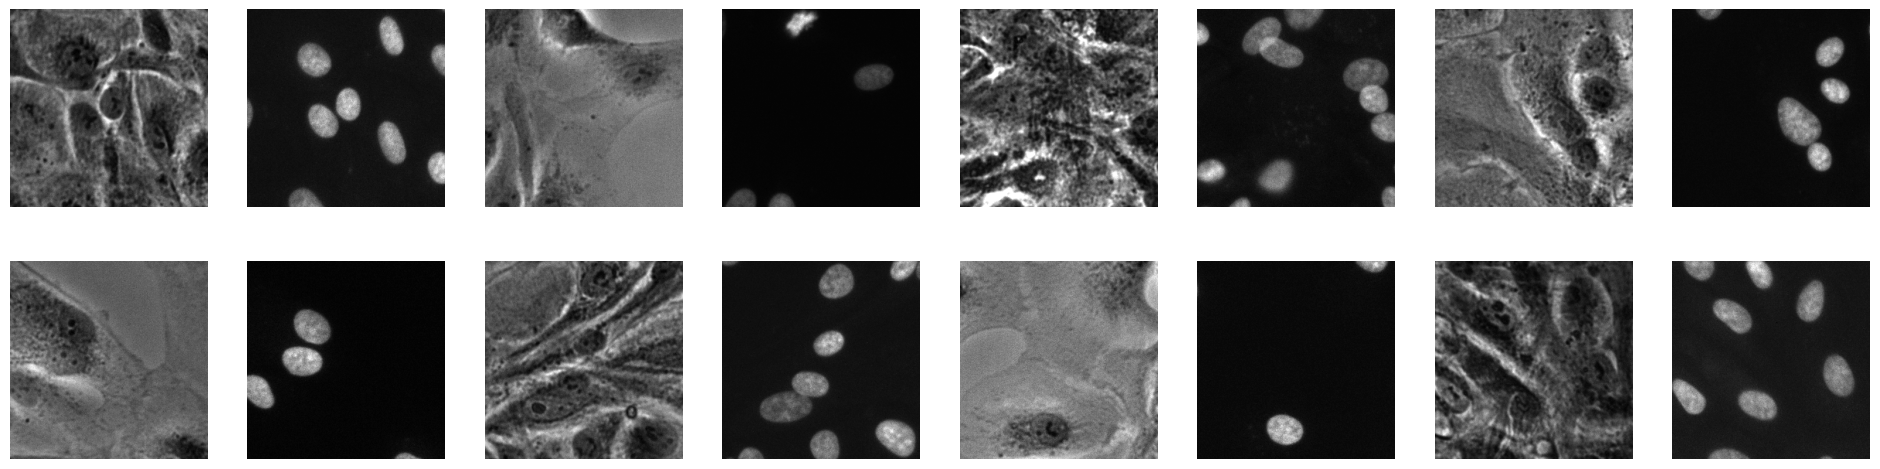

In [7]:
dls = dblock.dataloaders(path_x, bs=bs)
dls.show_batch(max_n=8, cmap='gray')

In [8]:
inputs, targets = dls.one_batch()
print(f'Inputs shape: {inputs.shape}, Targets shape: {targets.shape}')

# Asegúrate de que las dimensiones de entrada y salida sean las mismas
assert inputs.shape == targets.shape, "Dimensiones de entrada y salida no coinciden"

Inputs shape: torch.Size([8, 1, 256, 256]), Targets shape: torch.Size([8, 1, 256, 256])


In [9]:
from monai.networks.nets import BasicUNet, UNet # AttentionUnet, DynUNet, UNet, BasicUNet

In [10]:
# Definir el modelo U-Net

model = BasicUNet(spatial_dims=2, in_channels=1, out_channels=1)

#model = unet_learner(dls, resnet34, n_out=3, loss_func=MSELossFlat())

#model = cnn_learner(dls, resnet18,n_out=1, metrics=accuracy)

#model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 1, 1), num_res_units=1).model

# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))

BasicUNet features: (32, 32, 64, 128, 256, 32).


In [11]:
# learn = unet_learner(dls, resnet34, n_out=3, loss_func=MSELossFlat())
# learn.fine_tune(20)

In [12]:
from bioMONAI.losses import CombinedLoss
loss_func = mse #CombinedLoss()

In [13]:
from bioMONAI.losses import SSIMMetric

metrics = [mae, mse, SSIMMetric]

In [15]:
learn = Learner(dls, model, loss_func=loss_func, metrics=SSIMMetric, cbs=ShowGraphCallback())

epoch,train_loss,valid_loss,SSIM,time
0,0.107199,0.043330,0.029666,00:01
1,0.069829,0.022160,0.038516,00:01
2,0.052490,0.014506,0.101076,00:01
3,0.042038,0.011086,0.149288,00:01
4,0.035191,0.008260,0.236858,00:01
5,0.030416,0.007602,0.252934,00:01
6,0.026708,0.006116,0.328544,00:01
7,0.023865,0.005921,0.349254,00:01
8,0.021434,0.006152,0.359117,00:01
9,0.019514,0.005304,0.421287,00:01


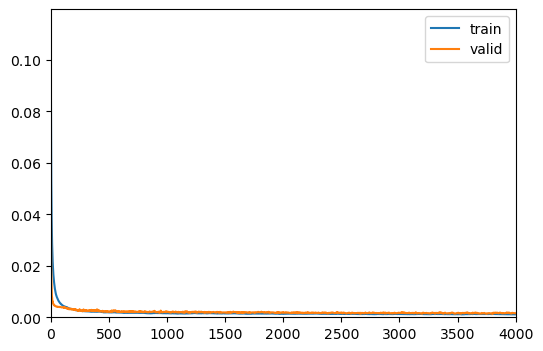

In [16]:
learn.fit(2000)

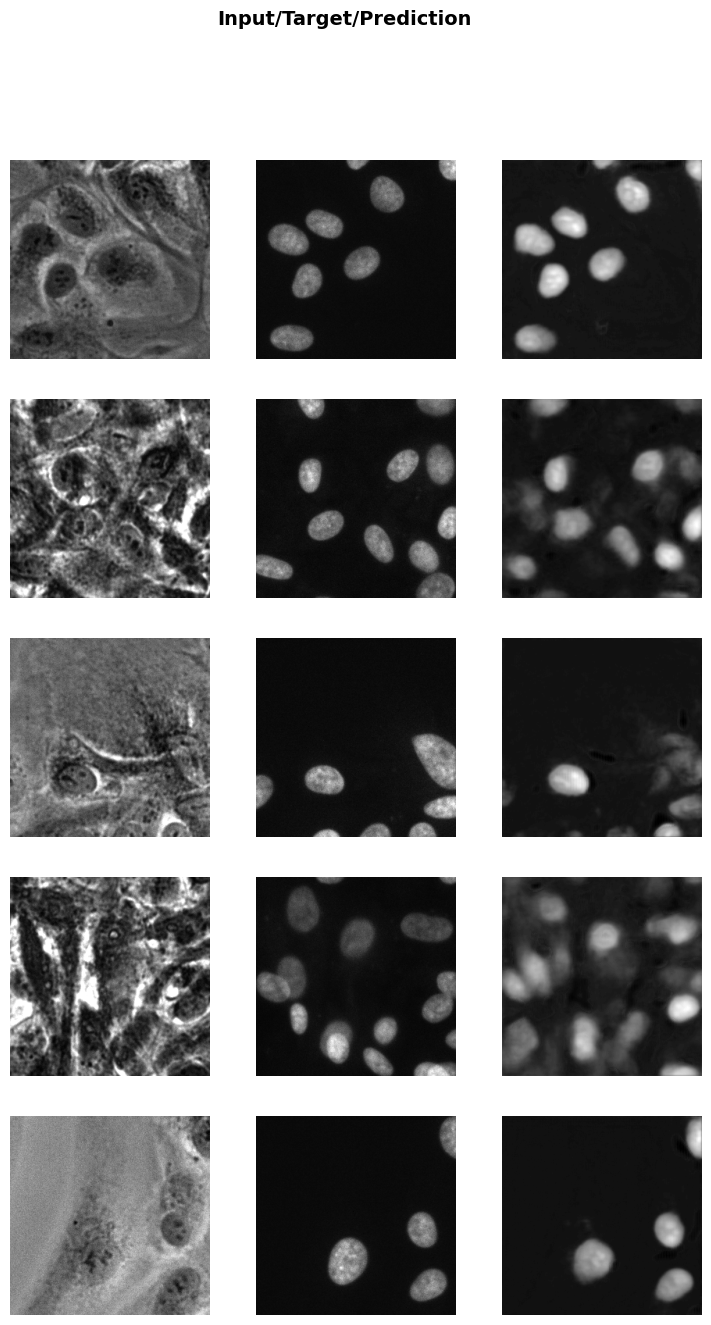

In [17]:
learn.show_results(cmap='gray')

In [18]:
image_path = '../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/inputs/sample_1.png'

image = Image.open(image_path).convert('L') 

array = np.array(image)

tensor = tensor1 = torch.from_numpy(array)

tensor = tensor.unsqueeze(0).unsqueeze(0)

tensor = tensor/255.0

tensor = tensor.to('cuda')

In [19]:
tensor = tensor[:,:,0:256,0:256]

In [20]:
output_tensor = model(tensor.to('cuda'))

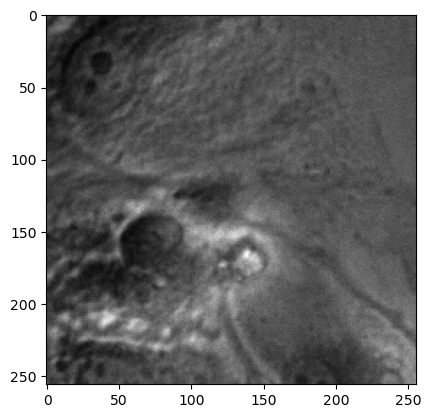

In [21]:
plt.imshow(array[0:256,0:256], cmap='gray')
plt.show()

In [22]:
# Convertir el tensor de PyTorch a un arreglo de numpy

output_tensor = output_tensor.cpu()
output_array = output_tensor.detach().numpy()

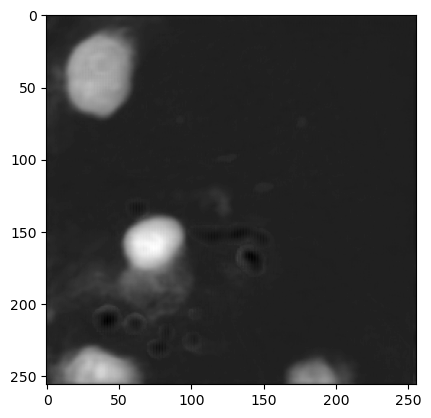

In [23]:
plt.imshow(output_array.squeeze((0,1)), cmap='gray')
plt.show()